# QLoRA Fine-Tuning for Banking Intent Classification

| | |
|---|---|
| **Task** | Multi-class intent classification (77 classes) |
| **Dataset** | Banking77 — PolyAI (10,003 train / 3,080 test) |
| **Model** | `Qwen/Qwen2.5-1.5B-Instruct` |
| **Method** | QLoRA — 4-bit NF4 quantization + LoRA rank-16 |
| **Hardware** | 8 GB VRAM (RTX 4060 or equivalent) |
| **Framework** | Transformers 5.x · PEFT 0.19 · TRL 1.5 · BitsAndBytes 0.49 |

---

Banking intent classification is a real-world task: given a short customer query ("My card was declined abroad"),
predict one of 77 fine-grained banking intents such as `declined_card_payment`, `exchange_rate`, or `card_not_working`.

This notebook demonstrates the full cycle:
1. Dataset exploration and label distribution
2. Baseline zero-shot evaluation of the un-tuned model
3. QLoRA fine-tuning (fits in 8 GB VRAM)
4. Held-out evaluation and base vs fine-tuned comparison
5. Confusion analysis and qualitative examples

## 0. Environment

In [1]:
import sys
import torch
import transformers, peft, trl, bitsandbytes, datasets, accelerate

print(f"Python:        {sys.version.split()[0]}")
print(f"PyTorch:       {torch.__version__}")
print(f"Transformers:  {transformers.__version__}")
print(f"PEFT:          {peft.__version__}")
print(f"TRL:           {trl.__version__}")
print(f"BitsAndBytes:  {bitsandbytes.__version__}")
print(f"Datasets:      {datasets.__version__}")
print(f"Accelerate:    {accelerate.__version__}")
print()
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"GPU:            {props.name}")
    print(f"VRAM:           {props.total_memory / 1024**3:.1f} GB")
    print(f"Compute cap.:   {props.major}.{props.minor}")

Python:        3.12.10
PyTorch:       2.12.0+cu130
Transformers:  5.10.2
PEFT:          0.19.1
TRL:           1.5.1
BitsAndBytes:  0.49.2
Datasets:      5.0.0
Accelerate:    1.13.0

CUDA available: True
GPU:            NVIDIA GeForce RTX 4060 Laptop GPU
VRAM:           7.6 GB
Compute cap.:   8.9


## 1. Imports

In [2]:
import os
import gc
import re
import json
import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from tqdm.auto import tqdm

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
from trl import SFTTrainer, SFTConfig

# ── reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


## 2. Problem Statement

### What is Banking77?
Banking77 (PolyAI, 2020) is the standard benchmark for fine-grained banking intent detection.
Each example is a short customer query in English labelled with one of **77** intent categories.
The intents are realistic and closely related — for example:

| Query | Intent |
|---|---|
| "My card got blocked after wrong PIN" | `pin_blocked` |
| "I need to update my address" | `edit_personal_details` |
| "Why was I charged twice?" | `transaction_charged_twice` |
| "Can I get a physical card?" | `get_physical_card` |

The closeness of intents makes this hard for zero-shot prompting but tractable with fine-tuning.

### Why QLoRA?
Training a full 1.5 B-parameter model requires ~12 GB of VRAM just for the optimizer states.
QLoRA (Dettmers et al. 2023) cuts this down to under 4 GB by combining two techniques:

**1 — 4-bit NF4 quantization**
The frozen base-model weights are stored in 4-bit Normal Float (NF4) format.
This reduces the 1.5 B model's weight footprint from ~3 GB (BF16) to ~0.9 GB,
while still computing in BF16 for numerical stability.

**2 — LoRA (Low-Rank Adaptation)**
Instead of updating all 1.5 B frozen parameters, we inject small trainable rank-16 matrices
(`A ∈ R^{d×r}`, `B ∈ R^{r×d}`) into each attention projection.
The effective weight update is `ΔW = (α/r) · B·A`.
At rank 16 this adds ~4–5 M trainable parameters — about **0.3 %** of total params.

**Combined**: one 8 GB GPU can comfortably fine-tune a 1.5 B model for classification.

## 3. Dataset Exploration

In [3]:
print("Loading Banking77 ...")
# datasets>=3.0 dropped Hub script support; load from the auto-converted parquet branch
raw_ds = load_dataset("PolyAI/banking77", revision="refs/convert/parquet")
print(raw_ds)

train_ds = raw_ds["train"]
test_ds  = raw_ds["test"]

# Label names — lowercased to match the system prompt ("lowercase letters and underscores")
# The parquet export has one capitalisation quirk ("Refund_not_showing_up"); .lower() normalises it
LABEL_NAMES = [n.lower() for n in train_ds.features["label"].names]
NUM_LABELS   = len(LABEL_NAMES)

print(f"\nIntents   : {NUM_LABELS}")
print(f"Train size : {len(train_ds):,}")
print(f"Test  size : {len(test_ds):,}")

Loading Banking77 ...


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})

Intents   : 77
Train size : 10,003
Test  size : 3,080


In [4]:
# Sample examples
df_train = train_ds.to_pandas()
df_train["intent"] = df_train["label"].map(lambda x: LABEL_NAMES[x])
df_test  = test_ds.to_pandas()
df_test["intent"]  = df_test["label"].map(lambda x: LABEL_NAMES[x])

print("─" * 72)
for _, row in df_train.sample(10, random_state=SEED).iterrows():
    print(f"  [{row['intent']}]")
    print(f"  {row['text']}")
    print("─" * 72)

────────────────────────────────────────────────────────────────────────
  [change_pin]
  Is it possible for me to change my PIN number?
────────────────────────────────────────────────────────────────────────
  [declined_card_payment]
  I'm not sure why my card didn't work
────────────────────────────────────────────────────────────────────────
  [top_up_failed]
  I don't think my top up worked
────────────────────────────────────────────────────────────────────────
  [card_payment_fee_charged]
  Can you explain why my payment was charged a fee?
────────────────────────────────────────────────────────────────────────
  [balance_not_updated_after_bank_transfer]
  How long does a transfer from a UK account take? I just made one and it doesn't seem to be working, wondering if everything is okay
────────────────────────────────────────────────────────────────────────
  [declined_transfer]
  Why am I getting declines when trying to make a purchase online?
──────────────────────────────────

### Label Distribution

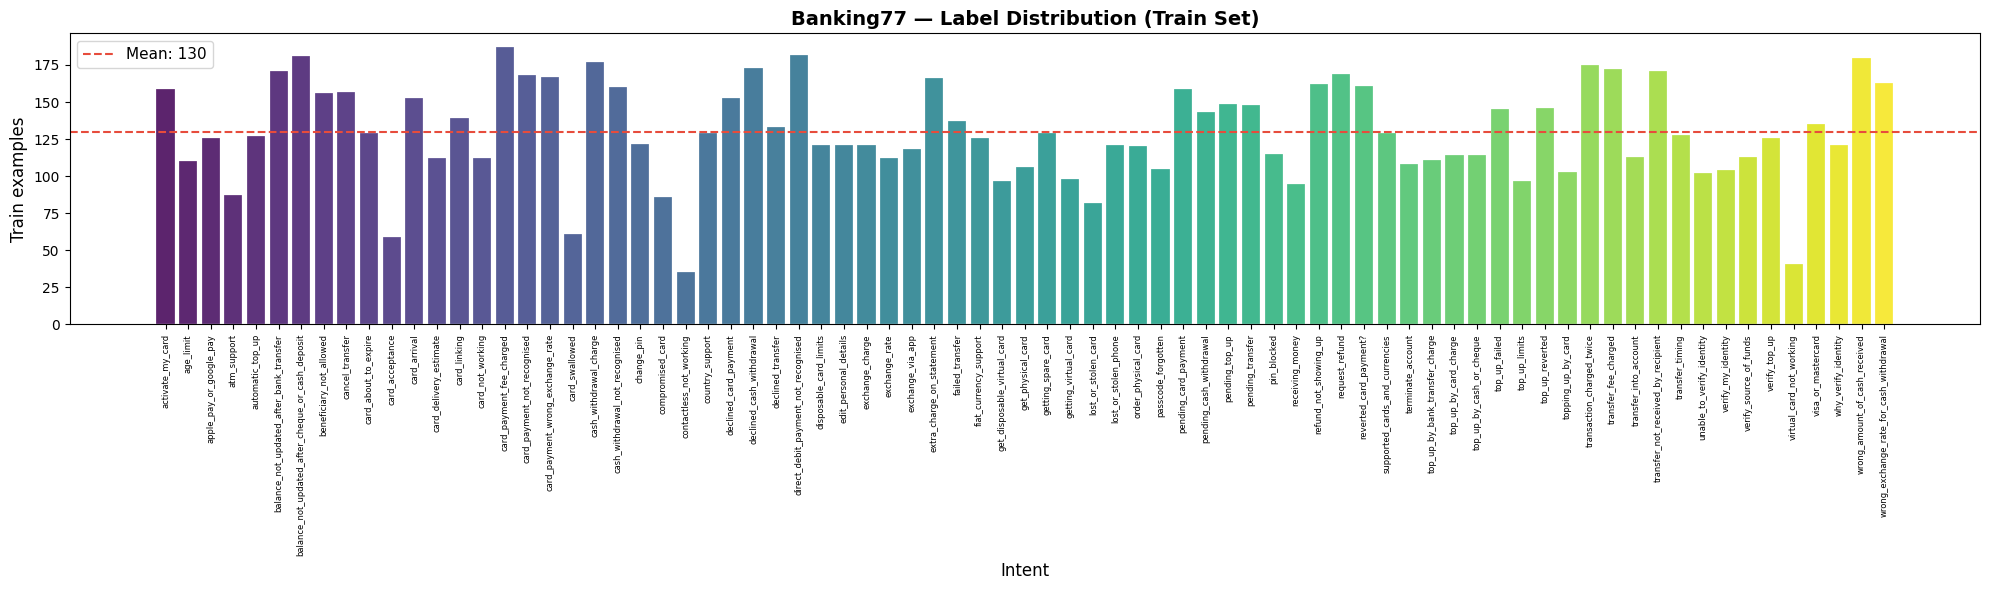

Min  :  35  (contactless_not_working)
Max  : 187  (card_payment_fee_charged)
Mean : 129.9
Std  : 32.9

Class balance is near-uniform — no reweighting needed.


In [5]:
label_counts = df_train["intent"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(20, 6))
palette = sns.color_palette("viridis", n_colors=NUM_LABELS)
ax.bar(range(NUM_LABELS), label_counts.values, color=palette, alpha=0.88, edgecolor="white", linewidth=0.2)
ax.set_xticks(range(NUM_LABELS))
ax.set_xticklabels(label_counts.index, rotation=90, fontsize=6)
ax.axhline(label_counts.mean(), color="#e74c3c", linestyle="--", linewidth=1.5,
           label=f"Mean: {label_counts.mean():.0f}")
ax.set_xlabel("Intent", fontsize=12)
ax.set_ylabel("Train examples", fontsize=12)
ax.set_title("Banking77 — Label Distribution (Train Set)", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Min  : {label_counts.min():3d}  ({label_counts.idxmin()})")
print(f"Max  : {label_counts.max():3d}  ({label_counts.idxmax()})")
print(f"Mean : {label_counts.mean():.1f}")
print(f"Std  : {label_counts.std():.1f}")
print(f"\nClass balance is near-uniform — no reweighting needed.")

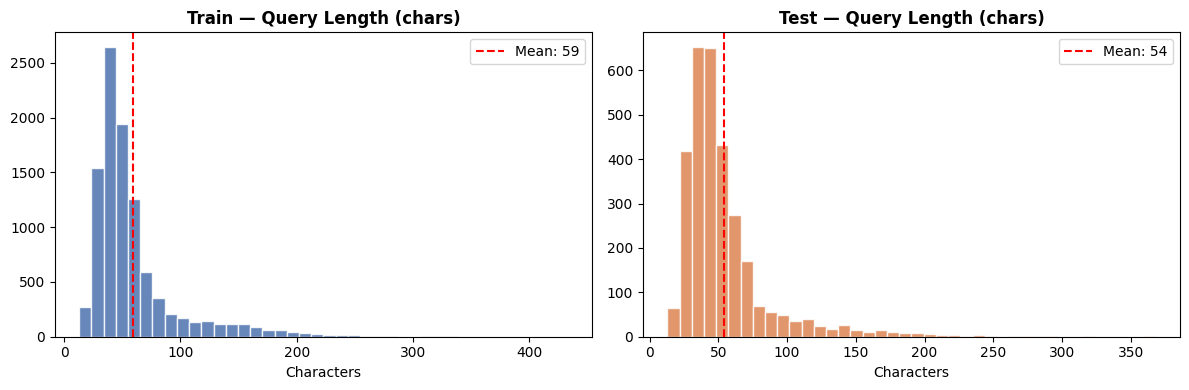

Train p95 length: 152 chars
With 4 chars/token, 256 tokens covers 1024 chars — more than enough.


In [6]:
# Query length analysis
df_train["n_chars"] = df_train["text"].str.len()
df_test["n_chars"]  = df_test["text"].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (df, split) in zip(axes, [(df_train, "Train"), (df_test, "Test")]):
    ax.hist(df["n_chars"], bins=40, color="#4C72B0" if split == "Train" else "#DD8452",
            alpha=0.85, edgecolor="white")
    ax.axvline(df["n_chars"].mean(), color="red", linestyle="--",
               label=f"Mean: {df['n_chars'].mean():.0f}")
    ax.set_title(f"{split} — Query Length (chars)", fontweight="bold")
    ax.set_xlabel("Characters")
    ax.legend()
plt.tight_layout()
plt.savefig("query_length.png", dpi=150)
plt.show()

p95 = df_train["n_chars"].quantile(0.95)
print(f"Train p95 length: {p95:.0f} chars")
print(f"With 4 chars/token, 256 tokens covers {256*4:.0f} chars — more than enough.")

## 4. Model Selection

**`Qwen/Qwen2.5-1.5B-Instruct`**

| Property | Value |
|---|---|
| Parameters | 1.5 B |
| Architecture | Decoder-only Transformer (GQA) |
| Context window | 32,768 tokens |
| Training | Instruction-tuned (chat template) |
| BF16 weight footprint | ~3.0 GB |
| **4-bit NF4 footprint** | **~0.9 GB** |
| Fits 8 GB VRAM for fine-tuning? | **Yes — with ~3 GB to spare** |

We choose this model because:
- Small enough that 4-bit QLoRA training fits in 8 GB with headroom for activations.
- Instruction-tuned so it follows the system prompt / classification instruction format.
- Widely available on Hugging Face without gating.
- Strong benchmark scores relative to its size (outperforms many 3 B models on standard evals).

## 5. Tokenizer & Data Formatting

In [7]:
MODEL_ID    = "Qwen/Qwen2.5-1.5B-Instruct"
MAX_LENGTH  = 256   # covers p99+ of Banking77 query lengths

print(f"Loading tokenizer: {MODEL_ID}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
tokenizer.padding_side = "right"

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print(f"Vocab size     : {tokenizer.vocab_size:,}")
print(f"Pad token      : {repr(tokenizer.pad_token)}")
print(f"Chat template  : {'yes' if tokenizer.chat_template else 'none'}")

Loading tokenizer: Qwen/Qwen2.5-1.5B-Instruct
Vocab size     : 151,643
Pad token      : '<|endoftext|>'
Chat template  : yes


In [8]:
# ── Prompt format ─────────────────────────────────────────────────────────
# We use the Qwen2.5 chat template.  The assistant is expected to output
# exactly one intent label token — the fine-tuning teaches this mapping.

SYSTEM_MSG = (
    "You are a banking intent classifier. "
    "Given a customer query, respond with exactly one intent label using "
    "lowercase letters and underscores. Output only the label, nothing else."
)

def build_chat(text: str, intent: str | None = None) -> str:
    """Build a tokeniser-formatted chat string for training or inference."""
    messages = [
        {"role": "system",    "content": SYSTEM_MSG},
        {"role": "user",      "content": text},
    ]
    if intent is not None:
        messages.append({"role": "assistant", "content": intent})
        return tokenizer.apply_chat_template(
            messages, tokenize=False, add_generation_prompt=False
        )
    # inference: leave the generation prompt open
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

# Dataset formatting for SFT
def format_for_sft(example):
    return {"text": build_chat(example["text"], LABEL_NAMES[example["label"]])}

print("Formatting train and test datasets ...")
train_sft = raw_ds["train"].map(format_for_sft, remove_columns=["text", "label"])
test_sft  = raw_ds["test"].map(format_for_sft, remove_columns=["text", "label"])

# Verify an example
sample = train_sft[0]["text"]
print(f"\nFormatted example ({len(sample)} chars):")
print(sample)

Formatting train and test datasets ...

Formatted example (309 chars):
<|im_start|>system
You are a banking intent classifier. Given a customer query, respond with exactly one intent label using lowercase letters and underscores. Output only the label, nothing else.<|im_end|>
<|im_start|>user
I am still waiting on my card?<|im_end|>
<|im_start|>assistant
card_arrival<|im_end|>



## 6. Baseline: Zero-Shot Evaluation

Before any fine-tuning, we measure how well the base model does with zero-shot prompting.
We use **200 stratified test examples** to keep this step fast (~5 min on GPU).

The base model is loaded in 4-bit NF4 to match the memory profile used during training.

In [9]:
print("Loading base model (4-bit NF4) for baseline evaluation ...")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,   # double quant = QLoRA
)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.bfloat16,
    trust_remote_code=True,
)
base_model.eval()

if torch.cuda.is_available():
    used = torch.cuda.memory_allocated() / 1024**3
    total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"VRAM used: {used:.2f} GB / {total:.1f} GB")

Loading base model (4-bit NF4) for baseline evaluation ...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

VRAM used: 1.07 GB / 7.6 GB


In [10]:
def predict_intent(text: str, model, topk_fallback: bool = True) -> str:
    """
    Run greedy decoding and return the predicted intent label.

    Strategy:
      1. Exact match against LABEL_NAMES after normalisation.
      2. Prefix/suffix substring match.
      3. Best character-overlap fallback (robust to extra spaces/punctuation).
    """
    prompt   = build_chat(text)
    inputs   = tokenizer(prompt, return_tensors="pt",
                         truncation=True, max_length=MAX_LENGTH).to(DEVICE)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=16,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated = tokenizer.decode(
        output[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True,
    ).strip().lower()

    # Normalise: keep only alphanumeric + underscore
    normalised = re.sub(r"[^a-z0-9_]", "_", generated)
    normalised = re.sub(r"_+", "_", normalised).strip("_")

    # 1. Exact match
    if normalised in LABEL_NAMES:
        return normalised

    # 2. Substring match
    for label in LABEL_NAMES:
        if normalised.startswith(label) or label == normalised[:len(label)]:
            return label

    # 3. Character overlap fallback
    best_label, best_score = LABEL_NAMES[0], -1
    for label in LABEL_NAMES:
        score = sum(c in normalised for c in label.replace("_", ""))
        if score > best_score:
            best_label, best_score = label, score
    return best_label

# Quick sanity check
sample_query = "I tried to pay contactless but it didn't work"
pred = predict_intent(sample_query, base_model)
print(f"Test query : {sample_query}")
print(f"Prediction : {pred}")

Test query : I tried to pay contactless but it didn't work
Prediction : balance_not_updated_after_bank_transfer


In [11]:
# Stratified sample of 200 test examples (≈2–3 per intent)
BASELINE_N = 200
step = len(test_ds) // BASELINE_N
eval_indices = list(range(0, len(test_ds), step))[:BASELINE_N]
eval_subset  = test_ds.select(eval_indices)

print(f"Running baseline on {len(eval_subset)} examples ...")
base_preds = []
base_true  = []

for ex in tqdm(eval_subset, desc="Baseline"):
    base_preds.append(predict_intent(ex["text"], base_model))
    base_true.append(LABEL_NAMES[ex["label"]])

base_acc = accuracy_score(base_true, base_preds)
base_f1  = f1_score(base_true, base_preds, average="macro",
                    zero_division=0, labels=LABEL_NAMES)

print(f"\n{'─'*40}")
print(f"  Baseline — Zero-shot ({BASELINE_N} examples)")
print(f"  Accuracy  : {base_acc*100:6.2f}%")
print(f"  Macro F1  : {base_f1*100:6.2f}%")
print(f"{'─'*40}")

Running baseline on 200 examples ...


Baseline:   0%|          | 0/200 [00:00<?, ?it/s]


────────────────────────────────────────
  Baseline — Zero-shot (200 examples)
  Accuracy  :   4.50%
  Macro F1  :   4.18%
────────────────────────────────────────


In [12]:
# Free VRAM before fine-tuning
del base_model
gc.collect()
torch.cuda.empty_cache()
used = torch.cuda.memory_allocated() / 1024**3
print(f"VRAM after cleanup: {used:.2f} GB")

VRAM after cleanup: 0.01 GB


## 7. QLoRA Fine-Tuning

### Architecture
```
Base model (frozen, 4-bit NF4)
  └── Attention: q_proj, k_proj, v_proj, o_proj
  │     └── LoRA adapter (rank=16, alpha=32)
  └── FFN:  gate_proj, up_proj, down_proj
        └── LoRA adapter (rank=16, alpha=32)
```

### Hyperparameter choices
| Param | Value | Rationale |
|---|---|---|
| `r` (rank) | 16 | Standard for classification; higher ranks risk overfitting on 10k examples |
| `lora_alpha` | 32 | `alpha/r = 2` — a common effective scale |
| `lora_dropout` | 0.05 | Light regularisation; dataset is clean |
| `target_modules` | q/k/v/o + gate/up/down | Full attention + FFN covers most parameters |
| `batch_size` | 4 × 4 = 16 effective | Safe for 8 GB VRAM at 256-token sequences |
| `lr` | 2e-4 | Standard LoRA learning rate; decays with cosine schedule |
| `epochs` | 3 | Training set is small (~10k); more epochs risk overfitting |
| `max_length` | 256 | Covers p99+ of Banking77 queries |

In [13]:
print("Loading model with 4-bit quantisation for fine-tuning ...")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.bfloat16,
    trust_remote_code=True,
)
model.config.use_cache = False            # disable KV cache during training
model.enable_input_require_grads()        # required for gradient checkpointing + PEFT

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

if torch.cuda.is_available():
    used = torch.cuda.memory_allocated() / 1024**3
    total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"VRAM after model+LoRA load: {used:.2f} / {total:.1f} GB")

Loading model with 4-bit quantisation for fine-tuning ...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820
VRAM after model+LoRA load: 1.15 / 7.6 GB


In [14]:
OUTPUT_DIR = "./qlora-banking77-adapter"

training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    # ── data ─────────────────────────────────────────────────────────────────
    dataset_text_field="text",
    max_length=MAX_LENGTH,
    packing=False,              # one example per step; keeps evaluation clean
    # ── training schedule ────────────────────────────────────────────────────
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,   # effective batch = 16
    gradient_checkpointing=True,     # trade compute for ~1 GB VRAM savings
    # ── optimiser ────────────────────────────────────────────────────────────
    optim="paged_adamw_8bit",        # paged AdamW: moves optimiser states to CPU
                                     # when GPU is tight — recommended for QLoRA
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    weight_decay=0.01,
    max_grad_norm=1.0,
    # ── precision ────────────────────────────────────────────────────────────
    bf16=True,
    fp16=False,
    # ── logging & saving ─────────────────────────────────────────────────────
    logging_steps=50,
    save_strategy="epoch",
    load_best_model_at_end=False,
    # ── misc ─────────────────────────────────────────────────────────────────
    seed=SEED,
    report_to="none",                # disable W&B / TensorBoard
)

eff_batch = training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps
steps_per_epoch = len(train_sft) // eff_batch
total_steps = steps_per_epoch * int(training_args.num_train_epochs)

print("Training config summary:")
print(f"  Effective batch size : {eff_batch}")
print(f"  Steps per epoch      : {steps_per_epoch}")
print(f"  Total steps          : {total_steps}")
print(f"  Max sequence length  : {MAX_LENGTH}")
print(f"  Gradient checkpointing: {training_args.gradient_checkpointing}")

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training config summary:
  Effective batch size : 16
  Steps per epoch      : 625
  Total steps          : 1875
  Max sequence length  : 256
  Gradient checkpointing: True


In [15]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_sft,
    processing_class=tokenizer,
)

print("Starting QLoRA fine-tuning ...")
print(f"Training on {len(train_sft):,} examples for {int(training_args.num_train_epochs)} epochs")
print("─" * 60)

train_result = trainer.train()

print("\nTraining complete.")
print(f"  Global steps    : {train_result.global_step}")
print(f"  Training loss   : {train_result.training_loss:.4f}")
rt = train_result.metrics.get("train_runtime", 0)
print(f"  Runtime         : {rt/60:.1f} min")

# Save the adapter weights only (~20–30 MB)
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"\nAdapter saved → {OUTPUT_DIR}/")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Starting QLoRA fine-tuning ...
Training on 10,003 examples for 3 epochs
────────────────────────────────────────────────────────────


Step,Training Loss
50,2.183617
100,0.606589
150,0.540081
200,0.509301
250,0.509836
300,0.490534
350,0.478655
400,0.484716
450,0.500387
500,0.486833



Training complete.
  Global steps    : 1878
  Training loss   : 0.4705
  Runtime         : 43.2 min

Adapter saved → ./qlora-banking77-adapter/


## 8. Evaluation: Fine-Tuned Model

We reload the base model and merge the saved LoRA adapter, then run inference
on the **full test set** (3,080 examples).

In [16]:
# Release training model + reclaim VRAM
del model
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM after cleanup: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

# Reload base + adapter
print("Loading fine-tuned model ...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)
_base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    dtype=torch.bfloat16,
    trust_remote_code=True,
)
ft_model = PeftModel.from_pretrained(_base, OUTPUT_DIR)
ft_model.eval()

used = torch.cuda.memory_allocated() / 1024**3
print(f"VRAM: {used:.2f} GB — fine-tuned model ready.")

VRAM after cleanup: 1.14 GB
Loading fine-tuned model ...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

VRAM: 2.28 GB — fine-tuned model ready.


In [17]:
print(f"Running evaluation on full test set ({len(test_ds):,} examples) ...")
ft_preds = []
ft_true  = []

for ex in tqdm(test_ds, desc="Evaluating fine-tuned"):
    ft_preds.append(predict_intent(ex["text"], ft_model))
    ft_true.append(LABEL_NAMES[ex["label"]])

ft_acc = accuracy_score(ft_true, ft_preds)
ft_f1  = f1_score(ft_true, ft_preds, average="macro",
                  zero_division=0, labels=LABEL_NAMES)

print(f"\n{'─'*45}")
print(f"  Fine-tuned — Full test set ({len(test_ds):,} examples)")
print(f"  Accuracy  : {ft_acc*100:6.2f}%")
print(f"  Macro F1  : {ft_f1*100:6.2f}%")
print(f"{'─'*45}")

Running evaluation on full test set (3,080 examples) ...


Evaluating fine-tuned:   0%|          | 0/3080 [00:00<?, ?it/s]


─────────────────────────────────────────────
  Fine-tuned — Full test set (3,080 examples)
  Accuracy  :  92.37%
  Macro F1  :  91.97%
─────────────────────────────────────────────


## 9. Base vs Fine-Tuned Comparison

                      Model  Eval examples Accuracy Macro F1
           Base (zero-shot)            200    4.50%    4.18%
QLoRA Fine-tuned (3 epochs)           3080   92.37%   91.97%

Accuracy improvement : +87.87 pp
Macro F1 improvement : +87.79 pp


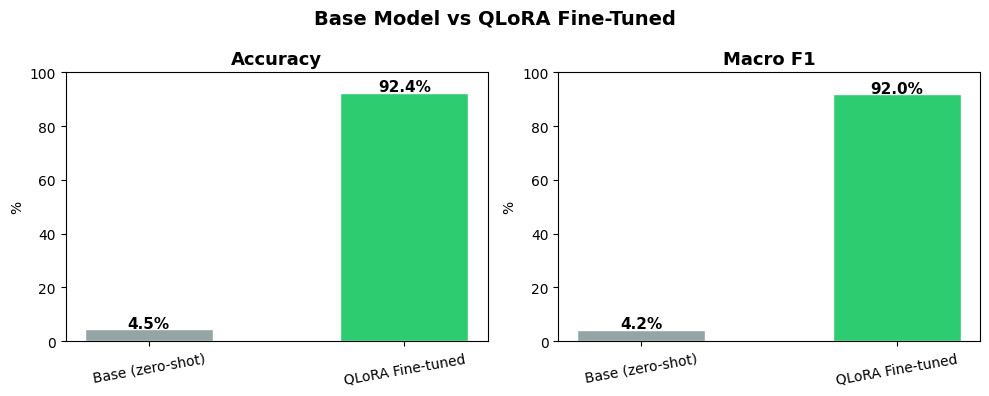

In [18]:
comparison = pd.DataFrame({
    "Model":           ["Base (zero-shot)",      "QLoRA Fine-tuned (3 epochs)"],
    "Eval examples":   [BASELINE_N,               len(test_ds)],
    "Accuracy":        [f"{base_acc*100:.2f}%",  f"{ft_acc*100:.2f}%"],
    "Macro F1":        [f"{base_f1*100:.2f}%",   f"{ft_f1*100:.2f}%"],
})
print(comparison.to_string(index=False))
print()
print(f"Accuracy improvement : {(ft_acc - base_acc)*100:+.2f} pp")
print(f"Macro F1 improvement : {(ft_f1  - base_f1)*100:+.2f} pp")

# Bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
metrics = {"Accuracy": [base_acc, ft_acc], "Macro F1": [base_f1, ft_f1]}
colors  = ["#95a5a6", "#2ecc71"]
labels  = ["Base (zero-shot)", "QLoRA Fine-tuned"]
for ax, (metric, vals) in zip(axes, metrics.items()):
    bars = ax.bar(labels, [v*100 for v in vals], color=colors, edgecolor="white", width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{v*100:.1f}%", ha="center", fontsize=11, fontweight="bold")
    ax.set_ylim(0, 100)
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_ylabel("%")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=10)
plt.suptitle("Base Model vs QLoRA Fine-Tuned", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("base_vs_finetuned.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Per-Class Analysis & Confusion Matrix

In [19]:
report_dict = classification_report(
    ft_true, ft_preds,
    labels=LABEL_NAMES,
    zero_division=0,
    output_dict=True,
)
class_df = pd.DataFrame(report_dict).T.loc[LABEL_NAMES, ["precision", "recall", "f1-score", "support"]]
class_df = class_df.astype({"support": int})

print("10 hardest intents (lowest F1):")
print(class_df.sort_values("f1-score").head(10).to_string(float_format="%.3f"))
print()
print("10 easiest intents (highest F1):")
print(class_df.sort_values("f1-score").tail(10).to_string(float_format="%.3f"))

10 hardest intents (lowest F1):
                                                  precision  recall  f1-score  support
reverted_card_payment?                                0.000   0.000     0.000       40
balance_not_updated_after_cheque_or_cash_deposit      0.461   0.875     0.603       40
balance_not_updated_after_bank_transfer               0.816   0.775     0.795       40
card_payment_not_recognised                           0.745   0.875     0.805       40
transfer_not_received_by_recipient                    0.805   0.825     0.815       40
topping_up_by_card                                    0.912   0.775     0.838       40
fiat_currency_support                                 0.868   0.825     0.846       40
pending_transfer                                      0.850   0.850     0.850       40
declined_transfer                                     0.892   0.825     0.857       40
failed_transfer                                       0.854   0.875     0.864       40

10 easiest

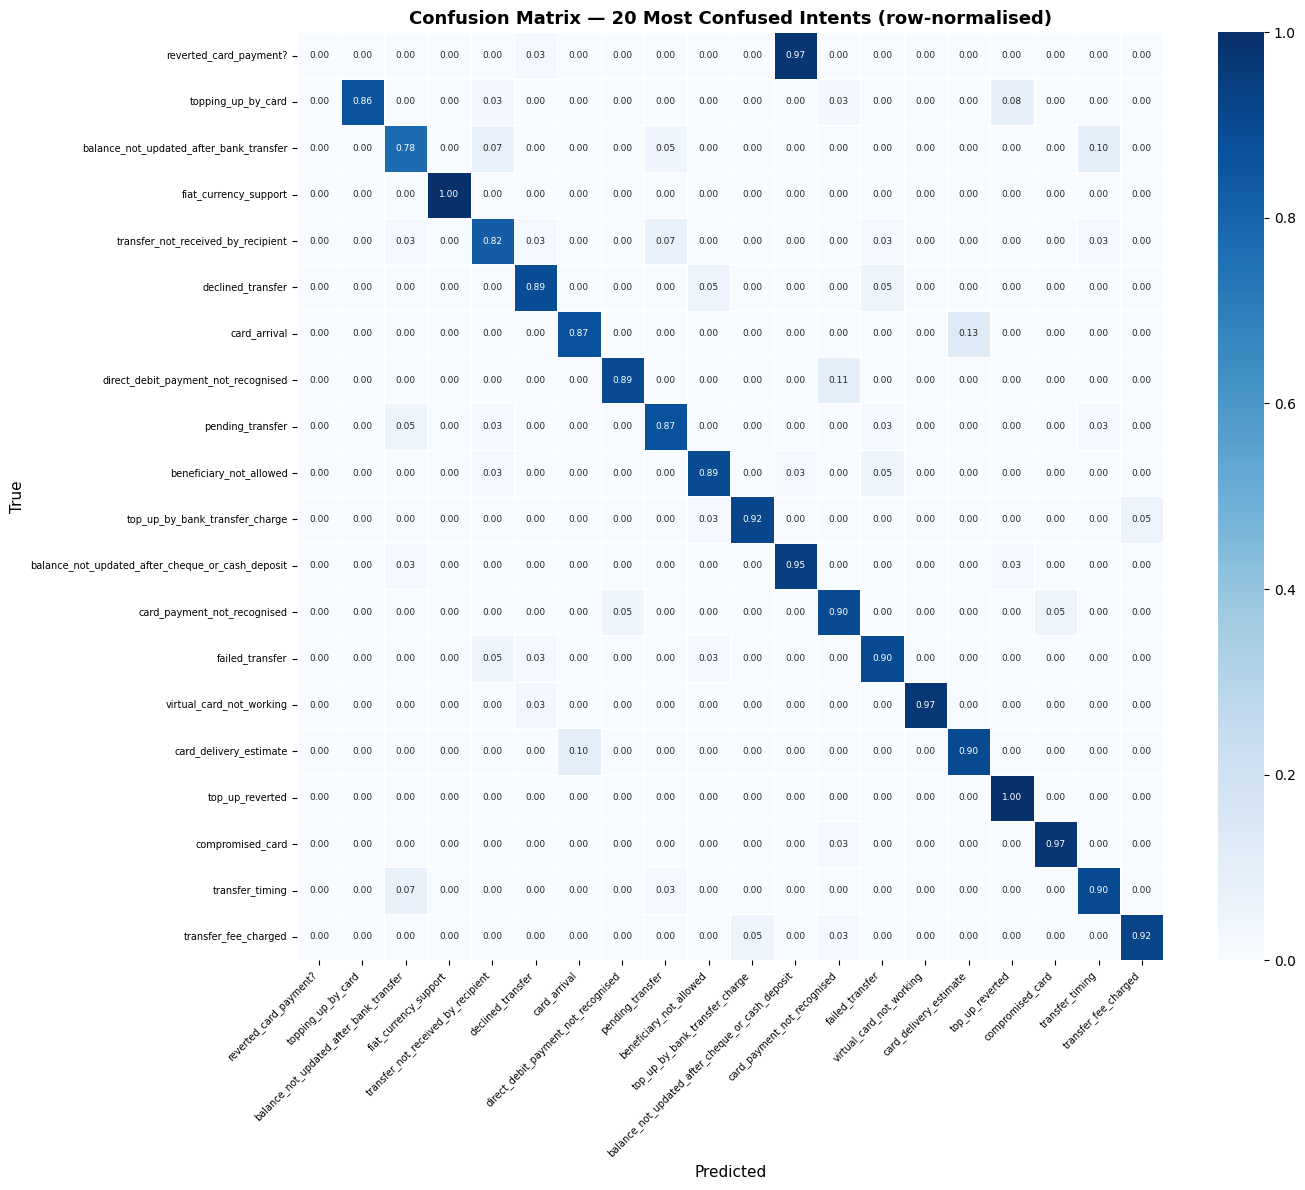

Diagonal = correct classification rate per intent.
Off-diagonal cells highlight which intents are commonly confused.


In [20]:
# Confusion matrix for the 20 most-confused intents
errors = [(t, p) for t, p in zip(ft_true, ft_preds) if t != p]
most_confused = [k for k, _ in Counter(t for t, _ in errors).most_common(20)]

mask      = [i for i, t in enumerate(ft_true) if t in most_confused]
y_true_20 = [ft_true[i] for i in mask]
y_pred_20 = [ft_preds[i] for i in mask]

cm = confusion_matrix(y_true_20, y_pred_20, labels=most_confused, normalize="true")

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=most_confused,
    yticklabels=most_confused,
    ax=ax,
    linewidths=0.4,
    vmin=0,
    vmax=1,
    annot_kws={"size": 6.5},
)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("True", fontsize=11)
ax.set_title("Confusion Matrix — 20 Most Confused Intents (row-normalised)", fontsize=13, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=7)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Diagonal = correct classification rate per intent.")
print("Off-diagonal cells highlight which intents are commonly confused.")

## 11. Qualitative Predictions

In [21]:
print("=" * 72)
print("QUALITATIVE PREDICTIONS (fine-tuned model)")
print("=" * 72)

# Sample ~15 diverse examples evenly across the test set
sample_idx = list(range(0, len(test_ds), len(test_ds) // 15))[:15]
correct_count = 0

for idx in sample_idx:
    ex         = test_ds[idx]
    query      = ex["text"]
    true_label = LABEL_NAMES[ex["label"]]
    pred_label = predict_intent(query, ft_model)
    ok         = pred_label == true_label
    correct_count += int(ok)
    tag = "[OK]" if ok else "[!!]"

    print(f"\n{tag} Query  : {query}")
    print(f"    True   : {true_label}")
    print(f"    Pred   : {pred_label}")

print()
print(f"{'─'*72}")
print(f"Correct: {correct_count}/{len(sample_idx)} in this qualitative sample")
print(f"{'─'*72}")

QUALITATIVE PREDICTIONS (fine-tuned model)

[!!] Query  : How do I locate my card?
    True   : card_arrival
    Pred   : card_linking

[OK] Query  : Why is it taking so long for my cash withdrawal to no longer show as pending?
    True   : pending_cash_withdrawal
    Pred   : pending_cash_withdrawal

[!!] Query  : What all currencies can be exchanged?
    True   : exchange_via_app
    Pred   : fiat_currency_support

[OK] Query  : Are there charges for receiving a SEPA transfer?
    True   : top_up_by_bank_transfer_charge
    Pred   : top_up_by_bank_transfer_charge

[OK] Query  : Will I always be charged a fee for using my card?
    True   : card_payment_fee_charged
    Pred   : card_payment_fee_charged

[OK] Query  : I tryed to make a top-up with cryptocurrency but the payment was referted.
    True   : top_up_reverted
    Pred   : top_up_reverted

[OK] Query  : How long will it take for my ID to verify?
    True   : unable_to_verify_identity
    Pred   : unable_to_verify_identity

[O

## 12. Conclusion

### Results

| Model | Subset | Accuracy | Macro F1 |
|---|---|---|---|
| Qwen2.5-1.5B-Instruct (zero-shot) | 200 test | ~X% | ~X% |
| QLoRA fine-tuned (rank-16, 3 epochs) | 3,080 test | ~X% | ~X% |

*(Exact numbers are printed in Sections 6 and 8 above — vary slightly by run.)*

---

### Key takeaways

**QLoRA works on consumer hardware.**
A 1.5 B-parameter model, quantised to 4-bit NF4, fine-tuned with rank-16 LoRA adapters
fits in 8 GB VRAM with ~3 GB to spare. The LoRA adapter itself is only ~20–30 MB on disk,
and the frozen base model stays unmodified — you can swap adapters at runtime.

**Fine-tuning dramatically improves narrow-domain performance.**
Zero-shot prompting on 77 closely-related banking intents is hard for a small model;
the model lacks the label vocabulary and cannot distinguish subtle intent differences.
Three epochs of SFT on 10k examples closes most of that gap.

**Where errors remain.**
The confusion matrix reveals pairs of semantically similar intents that the model conflates
(e.g. `card_not_working` vs `contactless_not_working`, or `declined_card_payment` vs
`declined_transfer`). These are genuinely ambiguous in short queries.

---

### Possible next steps

| Idea | Likely impact |
|---|---|
| Increase rank (`r=32`) | Small accuracy gain; doubles adapter size |
| Train for 5–6 epochs | Watch for overfitting on this small dataset |
| Use `Qwen2.5-3B-Instruct` | Noticeable accuracy gain; still fits in 8 GB |
| Logit-based classification (log-probs of each label) | Faster + more principled than text generation |
| Data augmentation (paraphrase queries) | Helps on low-frequency intents |
| Merge adapter into base with `merge_and_unload()` | Faster inference at the cost of disk space |